## Customer Segmentation Project


- Mall Customers dataset 
- we will implement K means clustering to check the spending patterns of our customers
- segment the customer spending behaviour


Task:
1. data ingestion/acquisition
2. Data EDA
3. Preprocessing, if needed
4. train a model 
5. Cluster the users 

Optional
6. Tag each cluter with a name and save that column in dataframe

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
df.head()

df.info()

# Dropping unrelated columns that are not needed in clusters

df = df.drop(columns = ['Gender','CustomerID'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [2]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


## Determine optimal number of k using elbow method analysis


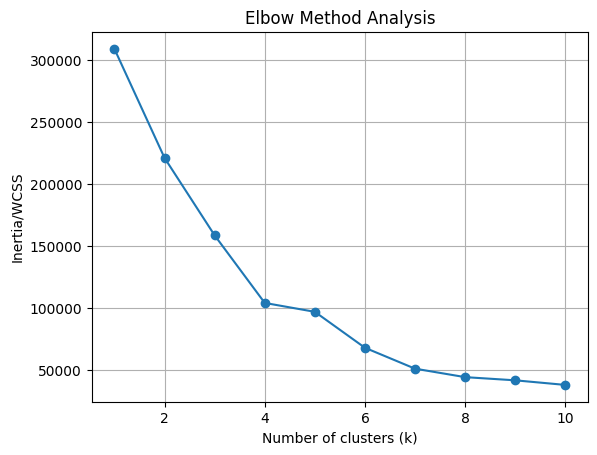

In [3]:
errors = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state= 42)
    kmeans.fit(df)
    errors.append(kmeans.inertia_)

plt.plot(range(1,11), errors, marker = 'o')
plt.title('Elbow Method Analysis')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia/WCSS')
plt.grid()
plt.show()

In [4]:
# Therefore 3 clusters were choosen
model = KMeans( n_clusters= 4, init = 'random', random_state= 42)

model

,n_clusters,4
,init,'random'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [5]:
df['Cluster'] = model.fit_predict(df)

In [6]:
# how far spread out the clusters are
# how good the model is
model.inertia_

104366.15145556201

In [7]:
df.sample(5)

df['Cluster'].value_counts()

Cluster
0    95
2    39
3    38
1    28
Name: count, dtype: int64

In [8]:
# Checking the mean of each clusters for each column
cluster_profiles = df.groupby('Cluster').mean()
print(cluster_profiles)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        44.894737           48.705263               42.631579
1        24.821429           28.714286               74.250000
2        32.692308           86.538462               82.128205
3        40.394737           87.000000               18.631579


#### Here we can see the group behaviour through mean value

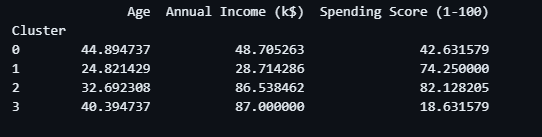

- Cluster 1 are oldest has medium spending score with medium income
- Cluster 2 are young adults has high spending score but has low income
- Cluster 3 are mature adults has high spending score and high income
- Cluster 4 are middle age adults has lowest spending score and highest income
